In [30]:
import json
import numpy as np
import rasterio
from pathlib import Path
import pickle
import pandas as pd
import os
import sys
import matplotlib
matplotlib.use("Agg")  # non-interactive backend, safe for HPC/headless runs
import matplotlib.pyplot as plt
import numpy as np
import time
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import hdbscan
from hdbscan.validity import validity_index
from hdbscan import approximate_predict

In [31]:
def build_config_path(config_filename):
    cwd = Path(os.getcwd())
    config_path = cwd / "configs" / config_filename
    return config_path


def load_config(config_path):
    with open(config_path, "r") as f:
        return json.load(f)


def resolve_paths(config):
    year = config['year']
    root = Path(config["data_path"]) / year
    for layer in config["metric_layers"]:
        p = Path(layer["path"])
        layer["path"] = str(p) if p.is_absolute() else str(root / p)
        layer["path"] = layer["path"].replace('YYYY', year)
    for layer in config["qa_layers"]:
        p = Path(layer["path"])
        layer["path"] = str(p) if p.is_absolute() else str(root / p)
        layer["path"] = layer["path"].replace('YYYY', year)
    return config


def build_output_dir(config):
    script_path = Path(config["script_path"])
    results_dir = script_path / "results" / config["run_name"]
    results_dir.mkdir(parents=True, exist_ok=True)
    return results_dir


def load_metric_stack(metric_layers,):
    bands = []
    names = []
    profile = None
    for layer in metric_layers:
        with rasterio.open(layer["path"]) as src:
            bands.append(src.read(1).astype(np.float32))
            names.append(layer["name"])
            if profile is None:
                profile = src.profile
    stack = np.stack(bands, axis=-1)
    return stack, names, profile


def build_qa_mask(qa_layers, shape, logic="AND"):
    masks = []
    for layer in qa_layers:
        with rasterio.open(layer["path"]) as src:
            qa = src.read(1)
        low, high = layer["valid_range"]
        masks.append((qa >= low) & (qa <= high))

    if logic == "AND":
        mask = np.logical_and.reduce(masks)
    elif logic == "OR":
        mask = np.logical_or.reduce(masks)
    else:
        raise ValueError(f"Unsupported qa_logic: {logic}")
    return mask

def preprocess(X, feature_names, scaling="standard"):
    X = X.copy()

    if scaling == "standard":
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    elif scaling == "none":
        scaler = None
        X_scaled = X
    else:
        raise ValueError(f"Unsupported scaling: {scaling}")

    return X_scaled, scaler, feature_names


In [44]:
import numpy as np
import pandas as pd
import rasterio
from sklearn.cluster import KMeans


def load_landcover_mask(landcover_path):
    """
    Load a single-band land cover classification raster.

    Inputs
    ------
    landcover_path : pathlib.Path or str
        Path to a single-band GeoTIFF where pixel values encode land cover
        class (0 = skip/no-data, 1 = shrub, 2 = tree, 3 = bare).

    Outputs
    -------
    landcover : np.ndarray, shape (H, W), dtype int
        2D array of class labels for the full raster extent.
    """
    with rasterio.open(landcover_path) as src:
        landcover = src.read(1)
    return landcover


def drop_top_half(landcover):
    """
    Exclude the top half of the raster by setting those rows to 0 (skip).

    Inputs
    ------
    landcover : np.ndarray, shape (H, W)
        Land cover class raster.

    Outputs
    -------
    landcover_out : np.ndarray, shape (H, W)
        Copy of input with rows [0 : H // 2] set to 0. Bottom half unchanged.
    """
    landcover_out = landcover.copy()
    h = landcover_out.shape[0]
    landcover_out[: h // 2, :] = 0
    return landcover_out

def drop_left_part(landcover):
    # set leftmost 100 to 0
    landcover_out = landcover.copy()
    w = landcover_out.shape[1]
    landcover_out[:, :100] = 0
    return landcover_out


def build_valid_mask(landcover, qa_mask):
    """
    Combine QA mask with land cover mask to produce final valid-pixel mask.

    Inputs
    ------
    landcover : np.ndarray, shape (H, W)
        Land cover class raster (0 = skip, 1/2/3 = classes). Top-half rows
        assumed already zeroed out by drop_top_half().
    qa_mask : np.ndarray, shape (H, W), dtype bool
        Boolean QA mask, True = valid pixel.

    Outputs
    -------
    valid_mask : np.ndarray, shape (H, W), dtype bool
        True where QA is valid AND land cover class is non-zero.
    """
    valid_mask = qa_mask & (landcover != 0)
    return valid_mask


def count_class_pixels(landcover, valid_mask, class_values=(1, 2, 3, 4)):
    """
    Count the number of valid pixels per land cover class.

    Inputs
    ------
    landcover : np.ndarray, shape (H, W)
        Land cover class raster.
    valid_mask : np.ndarray, shape (H, W), dtype bool
        Boolean mask of valid pixels.
    class_values : tuple of int
        Land cover class values to count. Default (1, 2, 3, 4).

    Outputs
    -------
    counts : pd.Series
        Pixel count per class, indexed by class value.
    """
    labels = landcover[valid_mask]
    counts = pd.Series(
        {c: int((labels == c).sum()) for c in class_values},
        name="pixel_count",
    )
    counts.index.name = "class"
    return counts


def extract_valid_pixels(stack, landcover, valid_mask):
    """
    Extract phenology metric vectors and class labels at valid pixels.

    Inputs
    ------
    stack : np.ndarray, shape (H, W, n_metrics)
        Phenology metric stack from load_metric_stack().
    landcover : np.ndarray, shape (H, W)
        Land cover class raster.
    valid_mask : np.ndarray, shape (H, W), dtype bool
        Boolean mask of valid pixels.

    Outputs
    -------
    X : np.ndarray, shape (n_valid, n_metrics)
        Per-pixel metric values at valid locations.
    y : np.ndarray, shape (n_valid,)
        Land cover class label at each valid pixel.
    """
    X = stack[valid_mask, :]
    y = landcover[valid_mask]
    return X, y


def class_mean_stats(X, y, feature_names, class_values=(1, 2, 3, 4)):
    """
    Compute per-class mean of each phenology metric.

    Inputs
    ------
    X : np.ndarray, shape (n_valid, n_metrics)
        Per-pixel metric values.
    y : np.ndarray, shape (n_valid,)
        Land cover class label at each pixel.
    feature_names : list of str
        Metric names, length n_metrics; used as DataFrame columns.
    class_values : tuple of int
        Land cover class values to report. Default (1, 2, 3, 4).

    Outputs
    -------
    stats : pd.DataFrame
        Rows indexed by class value, columns = feature_names, values = mean
        of that metric over pixels of that class.
    """
    rows = {c: X[y == c].mean(axis=0) for c in class_values}
    stats = pd.DataFrame.from_dict(rows, orient="index", columns=feature_names)
    stats.index.name = "class"
    return stats


def run_kmeans(X_scaled, n_clusters, random_state=42, n_init=10):
    """
    Fit KMeans on scaled per-pixel phenology metric vectors.

    Inputs
    ------
    X_scaled : np.ndarray, shape (n_valid, n_metrics)
        Standardized metric values (output of preprocess()).
    n_clusters : int
        Number of clusters. Default 3.
    random_state : int
        Seed for centroid initialization. Default 42.
    n_init : int
        Number of independent centroid initializations; best (lowest inertia)
        solution is returned. Default 10.

    Outputs
    -------
    labels : np.ndarray, shape (n_valid,)
        Cluster label (0 to n_clusters-1) for each pixel.
    model : sklearn.cluster.KMeans
        Fitted KMeans estimator.
    """
    model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)
    labels = model.fit_predict(X_scaled)
    return labels, model


def agreement_matrix(y, cluster_labels, n_clusters, class_values=(1, 2, 3, 4)):
    """
    Build a land-cover-vs-cluster agreement matrix.

    Inputs
    ------
    y : np.ndarray, shape (n_valid,)
        Land cover class label at each pixel.
    cluster_labels : np.ndarray, shape (n_valid,)
        KMeans cluster label at each pixel.
    class_values : tuple of int
        Land cover class values (row index). Default (1, 2, 3, 4).
    n_clusters : int
        Number of KMeans clusters (column index). Default 3.

    Outputs
    -------
    matrix : pd.DataFrame
        Rows indexed by land cover class value, columns indexed by cluster
        label (0 to n_clusters-1), values = pixel counts.
    """
    matrix = pd.DataFrame(
        0,
        index=list(class_values),
        columns=list(range(n_clusters)),
        dtype=int,
    )
    matrix.index.name = "class"
    matrix.columns.name = "cluster"
    for c in class_values:
        for k in range(n_clusters):
            matrix.loc[c, k] = int(((y == c) & (cluster_labels == k)).sum())
    return matrix

In [63]:
K = 4

In [ ]:
# Cell: setup
config_path = build_config_path("Walnut_Gulch_Kendall_Grasslands_phenology_clustering_v1.json")
config = resolve_paths(load_config(config_path))
landcover_mask = Path("/projectnb/modislc/users/fache/qgis/Walnut_Gulch_Kendall_Grasslands/WKG_lc_mask_1.tif") # TODO
print(f'{landcover_mask=}')

# Cell: load rasters
stack, feature_names, profile = load_metric_stack(config["metric_layers"])
qa_mask = build_qa_mask(config["qa_layers"], stack.shape[:2], logic=config.get("qa_logic", "AND"))
landcover = load_landcover_mask(landcover_mask)

landcover_mask=PosixPath('/projectnb/modislc/users/fache/qgis/Walnut_Gulch_Kendall_Grasslands/WKG_lc_mask_1.tif')


In [ ]:
# Cell: mask
counts = count_class_pixels(landcover, qa_mask)
print(counts)

# landcover = drop_top_half(landcover) # TODO
landcover = drop_left_part(landcover) # TODO
counts = count_class_pixels(landcover, qa_mask)
print(counts)

valid_mask = build_valid_mask(landcover, qa_mask)
print(f'{valid_mask.shape=}')

class
1    6568
2     905
3    5655
4    1631
Name: pixel_count, dtype: int64
class
1    6468
2     805
3    5555
4    1531
Name: pixel_count, dtype: int64
valid_mask.shape=(3334, 3334)


In [39]:
# Cell: counts
counts = count_class_pixels(landcover, valid_mask)
print(counts)

class
1    6468
2     805
3    5555
4    1531
Name: pixel_count, dtype: int64


In [40]:
# Cell: extract + per-class means
X, y = extract_valid_pixels(stack, landcover, valid_mask)
stats = class_mean_stats(X, y, feature_names)
print(stats)

              OGI      50PCGI        OGMx        Peak         OGD      50PCGD  \
class                                                                           
1      171.531998  195.420532  219.711197  234.930420  252.293137  289.844940   
2      144.160248  189.042236  217.068329  230.952789  245.269562  279.349060   
3      180.338074  200.923309  219.650940  231.298477  243.746887  272.432220   
4      171.786407  198.742645  221.304382  234.241013  247.397125  274.549957   

             OGmn  
class              
1      328.748596  
2      325.530426  
3      327.870575  
4      319.352051  


In [ ]:
# Cell: kmeans + agreement
X_scaled, scaler, feature_names = preprocess(X, feature_names, scaling="standard")
cluster_labels, kmeans_model = run_kmeans(X_scaled, n_clusters=K) # TODO
matrix = agreement_matrix(y, cluster_labels, n_clusters=K)
print(matrix)

cluster     0     1     2     3
class                          
1        1795    80  2234  2359
2         591    79    68    67
3         724  4035   504   292
4         494   126   897    14


In [65]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


def build_cluster_raster(cluster_labels, valid_mask, shape, fill_value=-1):
    """
    Reconstruct a 2D cluster label raster from the flat per-pixel label array.

    Inputs
    ------
    cluster_labels : np.ndarray, shape (n_valid,)
        KMeans cluster label per valid pixel, in the same order produced by
        boolean indexing of valid_mask.
    valid_mask : np.ndarray, shape (H, W), dtype bool
        Boolean mask indicating which pixels contributed to clustering.
    shape : tuple of int
        Target raster shape (H, W). Should match the land cover raster.
    fill_value : int
        Sentinel value placed at invalid/masked pixels. Default -1.

    Outputs
    -------
    cluster_raster : np.ndarray, shape (H, W), dtype int
        2D raster with cluster labels at valid pixels and fill_value elsewhere.
    """
    cluster_raster = np.full(shape, fill_value, dtype=int)
    cluster_raster[valid_mask] = cluster_labels
    return cluster_raster


def plot_spatial_comparison(
    landcover,
    cluster_raster,
    n_clusters,
    class_values=(1, 2, 3, 4),
    class_names=("grass", "tree", "bare", 'shrub'),
    figsize=(14, 7),
    background_color="#e0e0e0",
):
    """
    Plot land cover and KMeans cluster rasters side-by-side over the bottom half.

    Both rasters are cropped to rows [H//2 : H, :] before plotting. Land cover
    classes are rendered with Set3 colormap slots 0-2; clusters use slots 3-5.
    Invalid/background pixels (landcover == 0 or cluster == -1) render in light
    gray. Discrete legends are attached below each subplot.

    Inputs
    ------
    landcover : np.ndarray, shape (H, W)
        Land cover class raster (0 = background/skip, otherwise class values).
    cluster_raster : np.ndarray, shape (H, W)
        Cluster label raster from build_cluster_raster() (-1 = background).
    class_values : tuple of int
        Land cover class values in the raster. Default (1, 2, 3, 4).
    class_names : tuple of str
        Display names matching class_values. Default ("grass", "tree", "bare").
    n_clusters : int
        Number of KMeans clusters. Default 3.
    figsize : tuple of float
        Matplotlib figure size in inches. Default (14, 7).
    background_color : str
        Hex color for invalid/background pixels. Default light gray "#e0e0e0".

    Outputs
    -------
    fig : matplotlib.figure.Figure
        The figure object containing both subplots.
    axes : np.ndarray of matplotlib.axes.Axes
        Array of the two Axes objects (left = land cover, right = clusters).
    """
    set3 = plt.get_cmap("Set3").colors
    lc_colors = [background_color] + [set3[i] for i in range(len(class_values))]
    cl_colors = [background_color] + [set3[i + len(class_values)] for i in range(n_clusters)]

    lc_cmap = ListedColormap(lc_colors)
    lc_boundaries = [-0.5] + [v + 0.5 for v in (0,) + tuple(class_values)]
    lc_norm = BoundaryNorm(lc_boundaries, lc_cmap.N)

    cl_cmap = ListedColormap(cl_colors)
    cl_boundaries = [-1.5] + [k + 0.5 for k in range(n_clusters)]
    cl_norm = BoundaryNorm(cl_boundaries, cl_cmap.N)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].imshow(landcover, cmap=lc_cmap, norm=lc_norm, interpolation="nearest")
    axes[0].set_title("Land cover")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    lc_patches = [Patch(facecolor=background_color, edgecolor="none", label="background")]
    for v, name, color in zip(class_values, class_names, lc_colors[1:]):
        lc_patches.append(Patch(facecolor=color, edgecolor="none", label=f"{v} - {name}"))
    axes[0].legend(handles=lc_patches, loc="lower center", bbox_to_anchor=(0.5, -0.15),
                   ncol=len(lc_patches), frameon=False)

    axes[1].imshow(cluster_raster, cmap=cl_cmap, norm=cl_norm, interpolation="nearest")
    axes[1].set_title("KMeans clusters")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    cl_patches = [Patch(facecolor=background_color, edgecolor="none", label="background")]
    for k, color in enumerate(cl_colors[1:]):
        cl_patches.append(Patch(facecolor=color, edgecolor="none", label=f"cluster {k}"))
    axes[1].legend(handles=cl_patches, loc="lower center", bbox_to_anchor=(0.5, -0.15),
                   ncol=len(cl_patches), frameon=False)

    plt.tight_layout()
    return fig, axes

In [66]:
cluster_raster = build_cluster_raster(cluster_labels, valid_mask, landcover.shape)

In [67]:
h, w = cluster_raster.shape

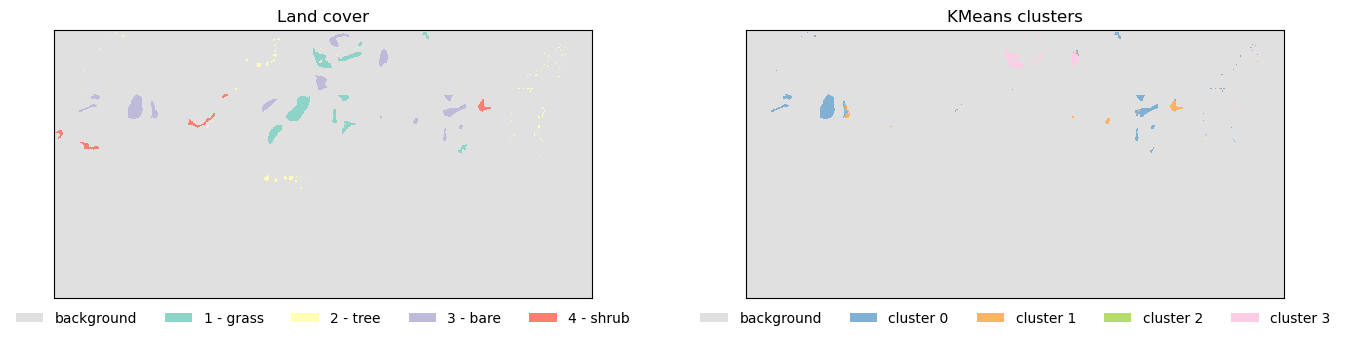

In [68]:
%matplotlib inline
fig, axes = plot_spatial_comparison(landcover[0 : h // 8, w * 3 // 4 :], cluster_raster[0 : h // 8, w * 3 // 4 :], n_clusters=K)
plt.show()